In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [3]:
dataset1 = pd.read_csv('/content/drive/MyDrive/deep learning exp/deep exp1 ds - Sheet1.csv')
X = dataset1[['input']].values
y = dataset1[['output']].values

In [ ]:
print(X)
print(y)

[[12]
 [ 2]
 [23]
 [ 4]
 [ 4]
 [ 5]
 [ 5]
 [ 4]
 [ 4]
 [34]
 [34]
 [56]
 [66]
 [22]
 [24]]
[[76]
 [76]
 [87]
 [66]
 [66]
 [43]
 [56]
 [ 6]
 [ 4]
 [ 3]
 [44]
 [67]
 [70]
 [43]
 [32]]


In [ ]:
dataset1.head()

,input,output
0,12,76
1,2,76
2,23,87
3,4,66
4,4,66


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        # Include your code here

        super().__init__()
        self.fc1=nn.Linear(1,8)
        self.fc2=nn.Linear(8,10)
        self.fc3=nn.Linear(10,1)
        self.relu=nn.ReLU()
        self.history={'loss': []}

  def forward(self,X):
    X=self.relu(self.fc1(X))
    X=self.relu(self.fc2(X))
    X=self.fc3(X)
    return X

In [ ]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
lig=NeuralNet()
criterion=nn.MSELoss()
optimizer=optim.RMSprop(lig.parameters(),lr=0.001)

In [ ]:
# Name:
# Register Number:
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
  for epoch in range(epochs):
    optimizer.zero_grad()
    loss= criterion(ai_brain(X_train),y_train)
    loss.backward()
    optimizer.step()
    lig.history['loss'].append(loss.item())
    if epoch % 200 == 0:
      print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


In [ ]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 3063.663818
Epoch [200/2000], Loss: 2311.780273
Epoch [400/2000], Loss: 1321.869873
Epoch [600/2000], Loss: 840.834290
Epoch [800/2000], Loss: 808.692200
Epoch [1000/2000], Loss: 807.381409
Epoch [1200/2000], Loss: 807.095520
Epoch [1400/2000], Loss: 807.091919
Epoch [1600/2000], Loss: 807.091797
Epoch [1800/2000], Loss: 807.091858


In [ ]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 542.205505


In [ ]:
loss_df = pd.DataFrame(lig.history)

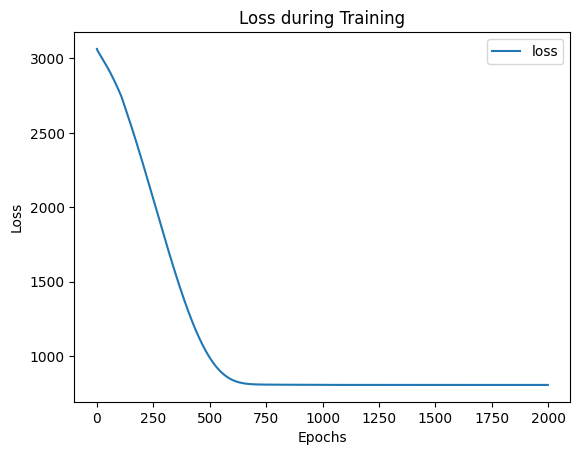

In [ ]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [ ]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 42.40656280517578
